# asymptotics — Boundary Layers (Matched Asymptotic Expansions)

**Singular perturbation problems** arise when ε multiplies the *highest derivative*:

$$\varepsilon u'' + p(x)\,u' + q(x)\,u = f(x), \qquad u(0) = \alpha,\quad u(1) = \beta$$

Setting ε=0 drops the equation from 2nd to 1st order — you can no longer satisfy both BCs. The solution develops a **boundary layer**: a thin region of thickness O(ε) near one boundary where it rapidly adjusts.

## The method: three pieces

| Piece | Where valid | How found |
|:---|:---:|:---|
| **Outer** $u^\text{out}(x)$ | Away from layer | Solve reduced ODE (ε=0), far BC |
| **Inner** $U(\xi)$ | Inside layer | Stretch: $\xi = x/\varepsilon$, near BC |
| **Composite** | Everywhere | $u^\text{out} + U(\xi) - u^\text{match}$ |

The **matching condition** — $\lim_{\xi\to\infty} U(\xi) = u^\text{out}(0)$ — links the two.

**Layer location** is determined automatically from the sign of $p(x)$:
- $p(0) > 0$ → layer at $x=0$
- $p(1) < 0$ → layer at $x=1$

In [2]:
from asymptotics import ODE
%config InlineBackend.figure_format = 'svg'

---
## Example 1 — Left boundary layer (constant coefficients)

$$\varepsilon u'' + u' + u = 0, \qquad u(0)=0,\quad u(1)=1$$

Here $p(x) = 1 > 0$, so the layer is at $x=0$. The stretched coordinate is $\xi = x/\varepsilon$.

In [25]:
eq1 = ODE(
    "eps*u'' + u' + u",
    small_param="eps",
    conditions=["u(0) = 0", "u(1) = 1"])
sol1 = eq1.expand_boundary_layer()
sol1.show()

  ℹ️  dependent = 'u' (inferred from conditions), independent = 'x' (inferred from equation)
     To override: ODE(..., dependent='u', independent='x')


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

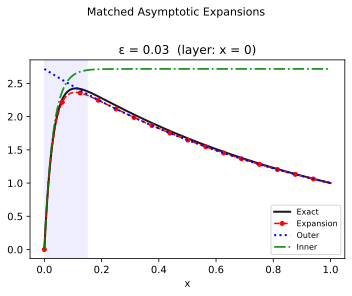

In [26]:
sol1.compare_numeric(eps = 0.03,plot_range=[0,1]);

In [27]:
sol1.to_latex()

% Matched asymptotic expansions

% Layer location: x = 0

% Stretched coordinate: xi = (x - layer) / eps



% Outer solution

\begin{align}
  u^{\text{out}}(x) &= e^{1 - x}
\end{align}


% Inner solution

\begin{align}
  U(\xi) &= e - e^{1 - \xi}
\end{align}


% Matching value: e



% Expansion solution (Van Dyke rule)

\begin{align}
  u^{\text{comp}}(x,\varepsilon) &= \left(1 - e^{\frac{x \left(\varepsilon - 1\right)}{\varepsilon}}\right) e^{1 - x}
\end{align}


'% Matched asymptotic expansions\n\n% Layer location: x = 0\n\n% Stretched coordinate: xi = (x - layer) / eps\n\n\n\n% Outer solution\n\n\\begin{align}\n  u^{\\text{out}}(x) &= e^{1 - x}\n\\end{align}\n\n\n% Inner solution\n\n\\begin{align}\n  U(\\xi) &= e - e^{1 - \\xi}\n\\end{align}\n\n\n% Matching value: e\n\n\n\n% Expansion solution (Van Dyke rule)\n\n\\begin{align}\n  u^{\\text{comp}}(x,\\varepsilon) &= \\left(1 - e^{\\frac{x \\left(\\varepsilon - 1\\right)}{\\varepsilon}}\\right) e^{1 - x}\n\\end{align}'

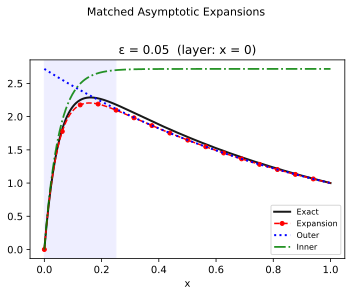

In [28]:
result = sol1.compare_numeric(eps=0.05, plot_range=[0, 1])

---
## Example 2 — Right boundary layer

$$\varepsilon u'' - u' + u = 0, \qquad u(0)=1,\quad u(1)=2$$

Now $p(x) = -1 < 0$, so the layer is at $x=1$. The stretched coordinate is $\xi = (1-x)/\varepsilon$.

The outer solution satisfying $u(0)=1$ is $u^\text{out} = e^x$. Since $e^1 \neq 2$, an inner correction is needed at $x=1$.

In [3]:
eq2 = ODE(
    "eps*u'' - u' + u",
    small_param="eps",
    conditions=["u(0) = 1", "u(1) = 2"])
sol2 = eq2.expand_boundary_layer()
sol2.show()

  ℹ️  dependent = 'u' (inferred from conditions), independent = 'x' (inferred from equation)
     To override: ODE(..., dependent='u', independent='x')


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

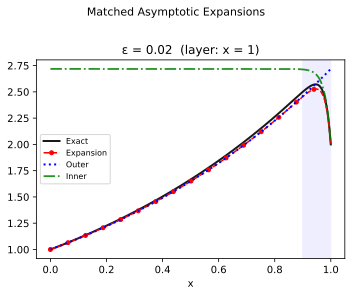

In [30]:
result = sol2.compare_numeric(eps=0.02, plot_range=[0, 1])

---
## Example 3 — Variable coefficients Boundary Layer

$$\varepsilon u'' + (1+x^2)\,u' - u = 0, \qquad u(0)=1,\quad u(1)=2$$

$p(x) = 1+x^2 > 0$ everywhere, so the layer is at $x=0$.

The outer ODE is $(1+x^2)\,u' - u = 0$.

In [5]:
eq3 = ODE(
    "eps*u'' + (1+x**2)*u' - u",
    small_param="eps",
    conditions=["u(0) = 1.5", "u(1) = 2"])
sol3 = eq3.expand_boundary_layer()
sol3.show()

  ℹ️  dependent = 'u' (inferred from conditions), independent = 'x' (inferred from equation)
     To override: ODE(..., dependent='u', independent='x')


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

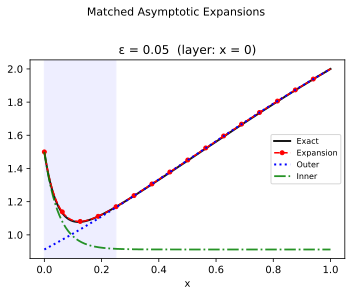

In [74]:
result = sol3.compare_numeric(eps=0.05, plot_range=[0, 1])

---
## Example 4 — No reaction term: pure advection-diffusion

$$\varepsilon u'' + u' = 0, \qquad u(0)=0,\quad u(1)=1$$

This is the simplest possible case — pure advection-diffusion with no reaction. The exact solution is:
$$u(x) = \frac{1 - e^{-x/\varepsilon}}{1 - e^{-1/\varepsilon}}$$

The composite solution: $u^\text{comp} = 1 - e^{-x/\varepsilon}$ (the outer is just 1).

In [75]:
eq4 = ODE(
    "eps*u'' + u'",
    dependent="u", small_param="eps", independent="x",
    conditions=["u(0) = 0", "u(1) = 1"])
sol4 = eq4.expand_boundary_layer()
sol4.show()

  ℹ️  dependent = 'u' (supplied), independent = 'x' (supplied)
     To override: ODE(..., dependent='u', independent='x')


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

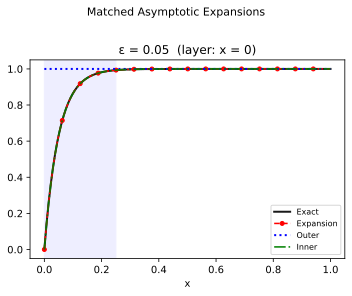

In [76]:
result = sol4.compare_numeric(eps=0.05, plot_range=[0, 1])

---
## Example 5 — Stronger damping

$$\varepsilon u'' + 2u' + u = 0, \qquad u(0)=0,\quad u(1)=1$$

The inner ODE now involves $p(0)=2$, giving a faster-decaying inner layer $e^{-2\xi}$.

In [77]:
eq5 = ODE(
    "eps*u'' + 2*u' + u",
    dependent="u", small_param="eps", independent="x",
    conditions=["u(0) = 0", "u(1) = 1"])
sol5 = eq5.expand_boundary_layer()
sol5.show()

  ℹ️  dependent = 'u' (supplied), independent = 'x' (supplied)
     To override: ODE(..., dependent='u', independent='x')


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

Inner solution U(ξ): (exp(2*xi) - 1)*exp(1/2 - 2*xi)


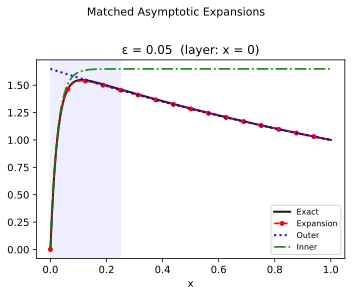

In [78]:
sol5.compare_numeric(eps=0.05, plot_range=[0, 1])
print('Inner solution U(ξ):', sol5.inner)

---
## Layer thickness: effect of ε

The boundary layer has thickness O(ε). As ε → 0, the layer gets thinner and the gradient steeper.

  ℹ️  dependent = 'u' (supplied), independent = 'x' (supplied)
     To override: ODE(..., dependent='u', independent='x')


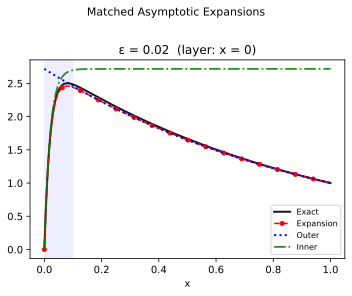

In [70]:
eq_demo = ODE(
    "eps*u'' + u' + u",
    dependent='u', small_param='eps', independent='x',
    conditions=['u(0) = 0', 'u(1) = 1'])
sol_demo = eq_demo.expand_boundary_layer()
result = sol_demo.compare_numeric(eps=0.02, plot_range=[0, 1])

---
## API quick reference

```python
from asymptotics import ODE

eq  = ODE("eps*u'' + p(x)*u' + q(x)*u",
          dependent="u", small_param="eps", independent="x",
          conditions=["u(0) = alpha", "u(1) = beta"])

sol = eq.expand_boundary_layer()   # order=0 (leading order)

# Display — shows outer, inner, composite separately
sol.show()

# Access results
sol.layer_location   # 'x = 0' or 'x = 1' — auto-detected
sol.outer            # u_out(x) — outer solution
sol.inner            # U(ξ) — inner in stretched coordinate
sol.inner_xi         # u_in(x) — inner in original x
sol.match            # matching constant
sol.expansion        # u_out + u_in - match
sol.outer_ode        # the reduced outer ODE
sol.inner_ode        # the inner ODE in ξ
sol.layer_var        # the ξ symbol
```

**Requirements:**
- 2nd-order ODE with ε multiplying u''
- BVP with conditions at two distinct points
- p(x) must have definite sign at one boundary:
  - p(0) > 0 → layer at x=0
  - p(1) < 0 → layer at x=1

**Variable coefficients** are fully supported — asymptotics uses SymPy's dsolve on the outer ODE.